### feature selection(변수 선택법)
* 필요한 변수만 선택하여 모델의 예측력을 높이거나 과적합을 줄이는 것
* 알고리즘의 정확도가 유사하다면 변수의 개수가 적을수록 속도가 빠르다
* 방법
    - L1(라쏘)을 이용하여 영향력이 0(작은)값을 빼는 방법
    - 단변량(filter) : 특정 컬럼이 또 다른 컬럼과 상관관계가 있는지 확인하는 방법
    - 전진/후진 선택법(wrapper) : 컬럼을 하나씩 추가하며 점수 확인 / 하나씩 빼며 점수 확인
    - RFE : 사이킷런에서 제공하는 라이브러리를 이용하여 변수의 중요도를 확인하여 변수를 선택하는 방법
    - embed(임베드) : 알고리즘의 성질 이용
        - 알고리즘 내부에서 각 feature 구송 요소들이 얼마나 사용 되었는지를 알아보는 방식
        - 알고리즘들을 이용해 변수의 중요도를 파악, 중요도 낮은 컬럼은 지울 수 있다
        - 참고
            * RFE와 embed 방식은 특정 알고리즘에 존재하며, 해당 방식을 사용할 수 없는 알고리즘들이 존재한다.(KNN, SVR(kernel=rbf)등 사용 못함)
            * Tree계열 알고리즘들은 사용 가능하다(Random Forest, Decision Tree 등)

In [2]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

In [5]:
df = pd.read_csv("../data_set/6.회귀/data_cleaning.csv")
df.head(1)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour,temp_int
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011,1,1,0,9


In [6]:
df.columns

Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count',
       'year', 'month', 'day', 'hour', 'temp_int'],
      dtype='object')

In [8]:
f = ['season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed', 'year', 'month', 'day', 'hour']
label = "count"
X,y = df[f], df[label]

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

### 모델 생성

In [11]:
model = RandomForestRegressor()
model.fit(X_train, y_train)
print("train : ", model.score(X_train, y_train))
print("test : ", model.score(X_test, y_test))

train :  0.991847104929918
test :  0.941252671741095


### 단변량(filter)
- feature 들의 상관관계가 높은건 제거

In [12]:
import seaborn as sns

<Axes: xlabel='temp', ylabel='atemp'>

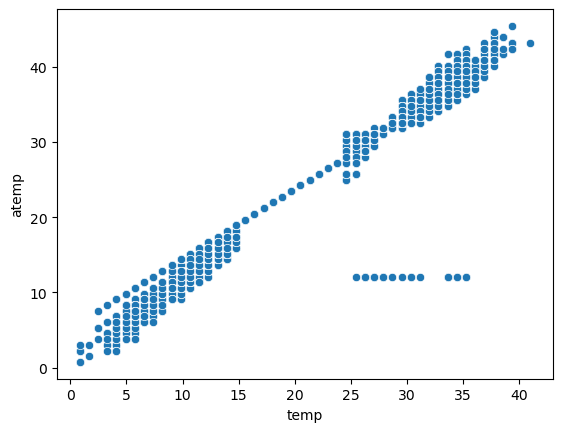

In [13]:
sns.scatterplot( data=df, x='temp', y='atemp')

In [14]:
df.corr(numeric_only=True)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour,temp_int
season,1.000000,0.029368,-0.008126,0.008879,0.258689,0.264744,0.190610,-0.147121,0.096758,0.164011,0.163439,-0.004797,0.971524,0.001729,-0.006546,0.257917
holiday,0.029368,1.000000,-0.250491,-0.007074,0.000295,-0.005215,0.001929,0.008409,0.043799,-0.020956,-0.005393,0.012021,0.001731,-0.015877,-0.000354,0.000192
workingday,-0.008126,-0.250491,1.000000,0.033772,0.029966,0.024660,-0.010880,0.013373,-0.319111,0.119460,0.011594,-0.002482,-0.003394,0.009829,0.002780,0.029603
weather,0.008879,-0.007074,0.033772,1.000000,-0.055035,-0.055376,0.406244,0.007261,-0.135918,-0.109340,-0.128655,-0.012548,0.012144,-0.007890,-0.022740,-0.054556
temp,0.258689,0.000295,0.029966,-0.055035,1.000000,0.984948,-0.064949,-0.017852,0.467097,0.318571,0.394454,0.061226,0.257589,0.015551,0.145430,0.999313
atemp,0.264744,-0.005215,0.024660,-0.055376,0.984948,1.000000,-0.043536,-0.057473,0.462067,0.314635,0.389784,0.058540,0.264173,0.011866,0.140343,0.984431
humidity,0.190610,0.001929,-0.010880,0.406244,-0.064949,-0.043536,1.000000,-0.318607,-0.348187,-0.265458,-0.317371,-0.078606,0.204537,-0.011335,-0.278011,-0.064205
windspeed,-0.147121,0.008409,0.013373,0.007261,-0.017852,-0.057473,-0.318607,1.000000,0.092276,0.091052,0.101369,-0.015221,-0.150192,0.036157,0.146631,-0.017660
casual,0.096758,0.043799,-0.319111,-0.135918,0.467097,0.462067,-0.348187,0.092276,1.000000,0.497250,0.690414,0.145241,0.092722,0.014109,0.302045,0.467047
registered,0.164011,-0.020956,0.119460,-0.109340,0.318571,0.314635,-0.265458,0.091052,0.497250,1.000000,0.970948,0.264265,0.169451,0.019111,0.380540,0.318048


In [15]:
import matplotlib.pyplot as plt

<Axes: >

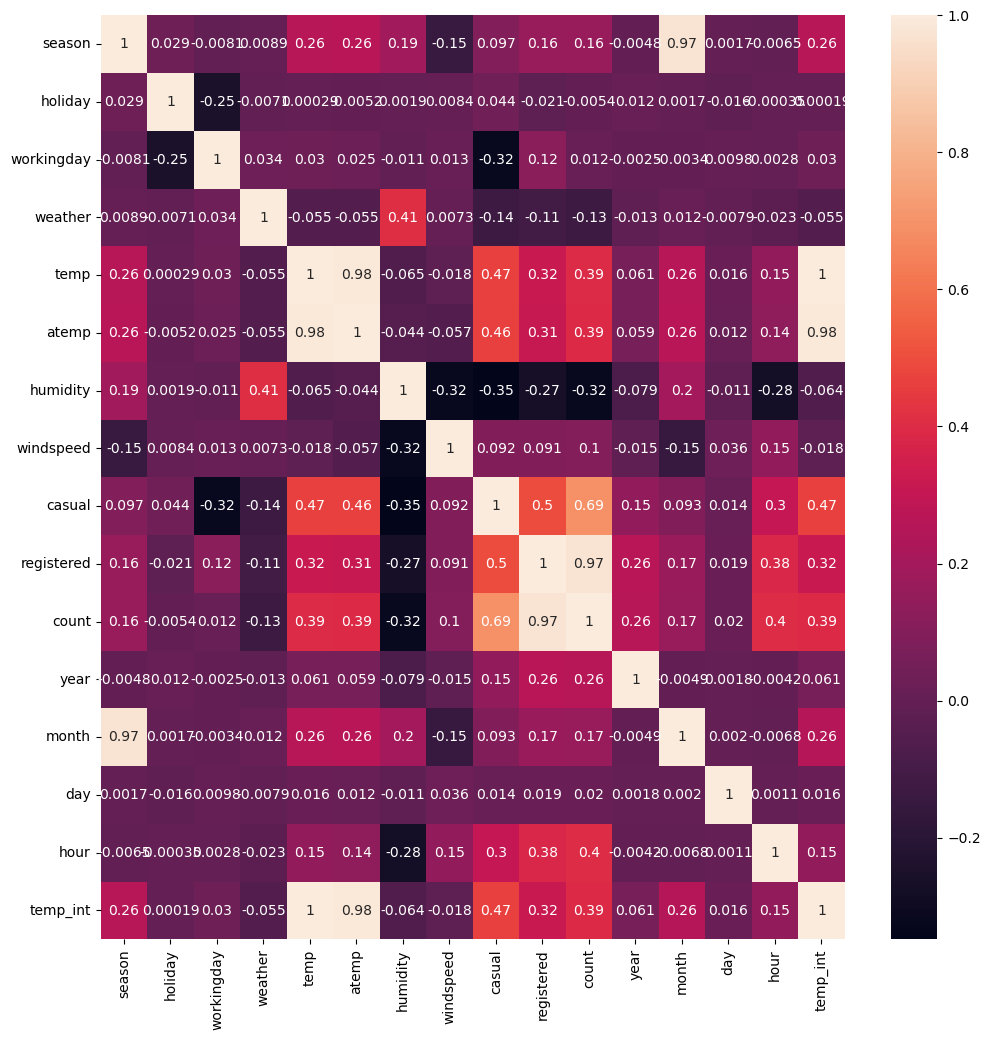

In [16]:
plt.subplots(figsize=(12,12))
sns.heatmap(df.corr(numeric_only=True), annot=True)

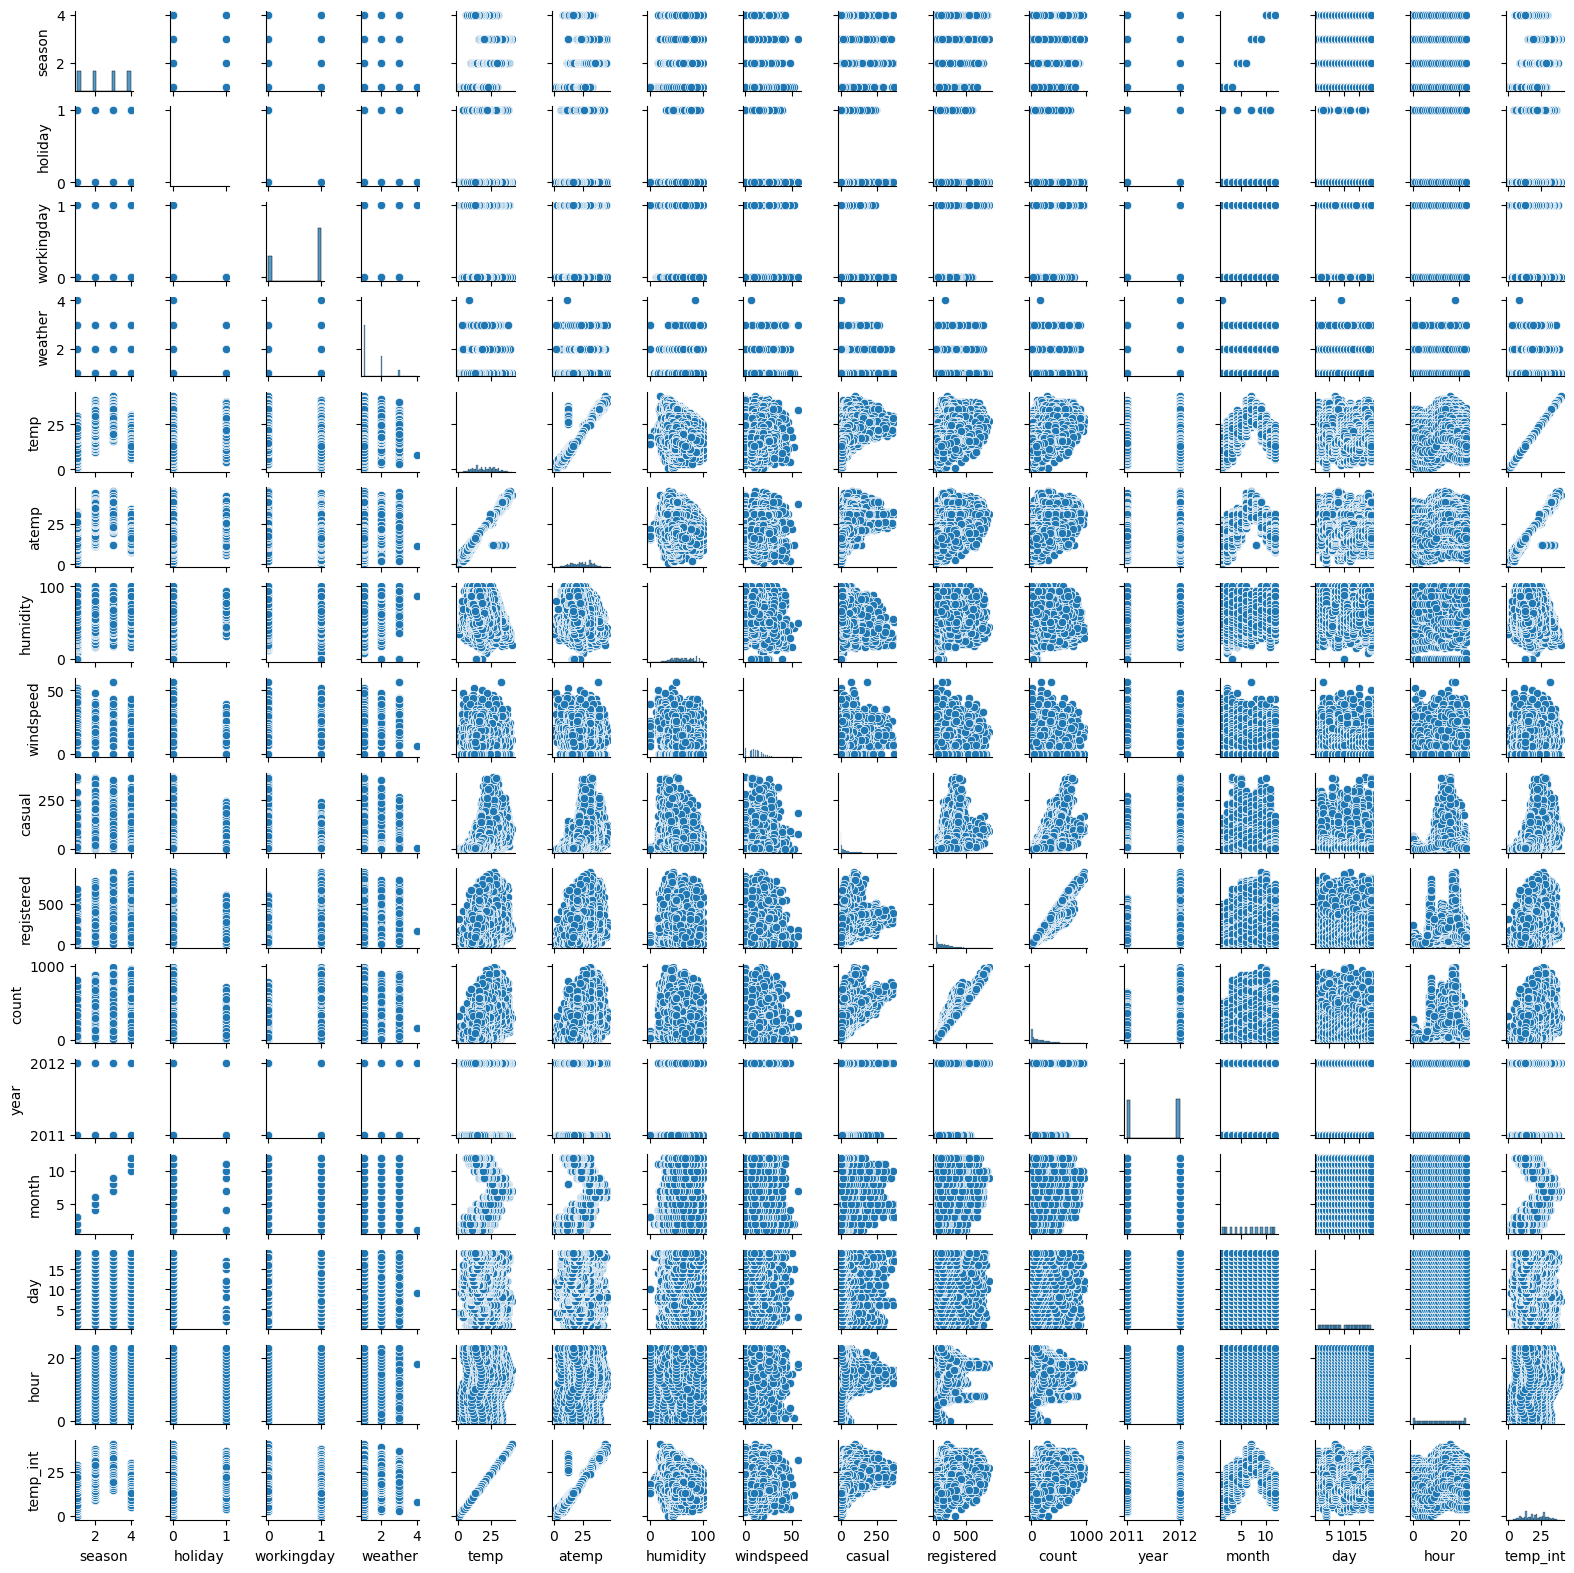

In [17]:
sns.pairplot(df, height=1)
plt.show()

In [19]:
print("이전 train : ", model.score(X_train , y_train) )
print("이전 test : ", model.score(X_test , y_test) )

이전 train :  0.991847104929918
이전 test :  0.941252671741095


In [20]:
f = ['season', 'holiday', 'workingday', 'weather', 'temp', 'humidity', 'windspeed', 'year', 'month', 'day', 'hour']
label = "count"
X, y = df[f], df[label]

X_train, X_test, y_train , y_test = train_test_split(X, y, test_size=0.3)

model = RandomForestRegressor()
model.fit(X_train ,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [21]:
print("train : ", model.score(X_train , y_train) )
print("test : ", model.score(X_test , y_test) )

train :  0.9918067772833888
test :  0.9353757150422033


### wrapper(전진/후진 선택)

##### 전진 선택

In [22]:
from itertools import combinations

In [23]:
sample_bag = [1,2,3,4]
for c in combinations(sample_bag, 2):
    print(c, type(c))

(1, 2) <class 'tuple'>
(1, 3) <class 'tuple'>
(1, 4) <class 'tuple'>
(2, 3) <class 'tuple'>
(2, 4) <class 'tuple'>
(3, 4) <class 'tuple'>


In [27]:
all_result = []
for c in combinations(f, 2):
    #print( c )

    X_train, X_test, y_train , y_test = train_test_split(df[list(c)], df['count'], test_size=0.3)
    
    model = RandomForestRegressor()
    model.fit(X_train ,y_train)
    
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    
    sub_result = {"combination":str(c), "train":train_score, "test":test_score}
    all_result.append(sub_result)

In [28]:
result_df = pd.DataFrame(all_result).sort_values(by="test")
result_df.tail()

,combination,train,test
9,"('season', 'hour')",0.617744,0.589183
39,"('temp', 'hour')",0.678980,0.599809
53,"('month', 'hour')",0.637037,0.608211
51,"('year', 'hour')",0.619983,0.619639
26,"('workingday', 'hour')",0.655236,0.651190


In [36]:
best_f = ['workingday', 'hour']
f = ['season', 'holiday', 'weather', 'temp', 'humidity', 'windspeed', 'year', 'month', 'day']

In [31]:
for c in f:
    best_f.append(c)
    print(best_f)
    best_f.pop()

['workingday', 'hour', 'season']
['workingday', 'hour', 'holiday']
['workingday', 'hour', 'weather']
['workingday', 'hour', 'temp']
['workingday', 'hour', 'humidity']
['workingday', 'hour', 'windspeed']
['workingday', 'hour', 'year']
['workingday', 'hour', 'month']
['workingday', 'hour', 'day']


In [34]:
all_result = []
for c in f:
    best_f.append(c)

    X_train, X_test, y_train , y_test = train_test_split(df[best_f], df['count'], test_size=0.3)
    
    model = RandomForestRegressor()
    model.fit(X_train ,y_train)
    
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    
    sub_result = {"best_f": best_f.copy(), "train":train_score, "test":test_score}
    all_result.append(sub_result)
    best_f.pop()

In [37]:
result_df = pd.DataFrame(all_result).sort_values(by="test")
result_df.tail()

,best_f,train,test
3,"[workingday, hour, season, holiday, weather, t...",0.991339,0.941101
5,"[workingday, hour, season, holiday, weather, t...",0.991883,0.942442
4,"[workingday, hour, season, holiday, weather, t...",0.991559,0.942772
8,"[workingday, hour, season, holiday, weather, t...",0.991444,0.943298
2,"[workingday, hour, season, holiday, weather, t...",0.991281,0.943344


#### 후진 선택법
##### 모든 feature를 추가 후 하나씩 빼면서 확인

In [44]:
f = ['season', 'holiday', 'workingday', 'weather', 'temp', 'humidity', 'year', 'month', 'day', 'hour']
label = "count"

In [45]:
print(type(f))
for item in combinations( f, len(f)-1 ):
    print(set(f) - set(item))

<class 'list'>
{'hour'}
{'day'}
{'month'}
{'year'}
{'humidity'}
{'temp'}
{'weather'}
{'workingday'}
{'holiday'}
{'season'}


In [46]:
all_result = []
for item in combinations(f, len(f) -1 ):
    #print( c )
    target = list(item)
    
    X_train, X_test, y_train , y_test = train_test_split(df[target], df['count'], test_size=0.3)
    
    model = RandomForestRegressor()
    model.fit(X_train ,y_train)
    
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)

    drop = set(f) - set(target)
    
    sub_result = {"drop feature": drop.pop(), "train":train_score, "test":test_score}
    all_result.append(sub_result)

In [47]:
result_df = pd.DataFrame(all_result).sort_values(by="test")
result_df

,drop feature,train,test
0,hour,0.866096,0.399708
7,workingday,0.972975,0.800360
3,year,0.980261,0.864830
4,humidity,0.990996,0.925971
6,weather,0.991423,0.931628
5,temp,0.990803,0.932132
8,holiday,0.991547,0.938324
2,month,0.991198,0.938452
1,day,0.991123,0.941689
9,season,0.991218,0.945909


#### RFE

In [48]:
f = ['season', 'holiday', 'workingday', 'weather', 'temp', 'humidity', 'year', 'month', 'day', 'hour']
label = "count"

X_train, X_test, y_train , y_test = train_test_split(df[f], df[label], test_size=0.3)
    
model = RandomForestRegressor()
#model.fit(X_train ,y_train)

In [49]:
from sklearn.feature_selection import RFE

In [50]:
rfe = RFE(estimator = model)
rfe.fit(X_train, y_train)
rfe_df = pd.DataFrame()
rfe_df['ranking'] = rfe.ranking_
rfe_df['feature'] = X_train.columns

In [51]:
rfe_df.sort_values(by="ranking")

,ranking,feature
2,1,workingday
4,1,temp
6,1,year
7,1,month
9,1,hour
5,2,humidity
8,3,day
3,4,weather
0,5,season
1,6,holiday


In [55]:
f = ['temp', 'year', 'month', 'hour', "workingday", "humidity"]
label = "count"

X_train, X_test, y_train , y_test = train_test_split(df[f], df[label], test_size=0.3)

model = RandomForestRegressor()
model.fit(X_train ,y_train)

print("train : ", model.score(X_train, y_train))
print("test : ", model.score(X_test, y_test))

train :  0.9889209661445787
test :  0.9254368832455921


#### 임베드 방식
- 트리계열에서 사용

In [57]:
f = ['season', 'holiday', 'workingday', 
     'weather', 'temp', 'humidity', 
     'year', 'month', 'day', 'hour']
label = "count"

X_train, X_test, y_train , y_test = train_test_split(df[f], df[label], test_size=0.3)
    
model = RandomForestRegressor()
model.fit(X_train ,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [58]:
print(model.feature_importances_)
X_train.columns

[0.00991271 0.00291548 0.06386478 0.01676927 0.1152226  0.03448095
 0.08383807 0.03784766 0.01510424 0.62004425]


Index(['season', 'holiday', 'workingday', 'weather', 'temp', 'humidity',
       'year', 'month', 'day', 'hour'],
      dtype='object')

In [59]:
rfe_df = pd.DataFrame()
rfe_df["rank"] = model.feature_importances_
rfe_df["feature"] = X_train.columns

In [60]:
rfe_df.sort_values(by="rank", ascending=False)

,rank,feature
9,0.620044,hour
4,0.115223,temp
6,0.083838,year
2,0.063865,workingday
7,0.037848,month
5,0.034481,humidity
3,0.016769,weather
8,0.015104,day
0,0.009913,season
1,0.002915,holiday
